# Занятие 12 (Доп). PINN на сложной геометрии (2D) #

В этом примере мы продемонстрируем главное преимущество нейросетевого подхода — **бессеточность (mesh-free)**.

### Проблема классических методов (FEM/FDM):
Для решения задачи на сложной фигуре (например, деталь двигателя) в классических методах необходимо:
1. Построить сетку (триангуляцию).
2. Следить за качеством элементов (чтобы не было слишком острых углов).
3. Перестраивать сетку при больших деформациях.

### Подход PINN:
Мы просто "набрасываем" облако точек внутрь области. Нейросети неважна связность точек, ей нужны только координаты $(x,y)$.

### Задача:
Решим уравнение Пуассона (стационарная теплопроводность с источником):
$$ -\Delta u = f(x,y) $$
$$ -(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}) = f(x,y) $$

В области $\Omega$ в виде **"Шестеренки"** (параметрически заданная кривая).

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"Device: {device}")

Device: cpu


## 1. Геометрия: Шестеренка (Gear) ##

Определим область с помощью полярных координат.
Граница задается уравнением:
$$ R(\phi) = 1 + 0.2 \sin(8\phi) $$
Это создает фигуру с 8 "зубьями".

In [2]:
def is_inside_gear(x, y):
    """
    Проверка, находится ли точка (x,y) внутри шестеренки.
    Используем полярные координаты.
    """
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    
    # Параметрическая граница
    r_boundary = 1.0 + 0.2 * np.sin(7 * phi)
    
    # Точка внутри, если её радиус меньше радиуса границы
    return r < r_boundary

In [3]:
def generate_gear_points(n_points):
    """
    Генерация облака точек методом Rejection Sampling (Монте-Карло).
    Мы берем случайные точки в квадрате и оставляем только те, что внутри шестеренки.
    """
    points = []
    while len(points) < n_points:
        # Генерируем с запасом в квадрате [-1.5, 1.5]
        batch_x = np.random.uniform(-1.3, 1.3, n_points)
        batch_y = np.random.uniform(-1.3, 1.3, n_points)
        
        # Проверяем условие
        mask = is_inside_gear(batch_x, batch_y)
        
        # Добавляем хорошие точки
        valid_points = np.column_stack([batch_x[mask], batch_y[mask]])
        points.extend(valid_points)
        
    return np.array(points[:n_points])

In [4]:
def get_boundary_points(n_points):
    """Генерация точек строго на границе"""
    phi = np.random.uniform(0, 2*np.pi, n_points)
    r = 1.0 + 0.2 * np.sin(7 * phi)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return np.column_stack([x, y])

In [5]:
# 1. Точки внутри области (Collocation points) для уравнения
XY_collocation = generate_gear_points(500)

x_col = torch.tensor(XY_collocation[:, 0:1], dtype=torch.float32).to(device)
y_col = torch.tensor(XY_collocation[:, 1:2], dtype=torch.float32).to(device)

# 2. Точки на границе (Boundary points) для граничных условий
XY_boundary = get_boundary_points(100)

x_bnd = torch.tensor(XY_boundary[:, 0:1], dtype=torch.float32).to(device)
y_bnd = torch.tensor(XY_boundary[:, 1:2], dtype=torch.float32).to(device)

## Визуализация облака точек ##

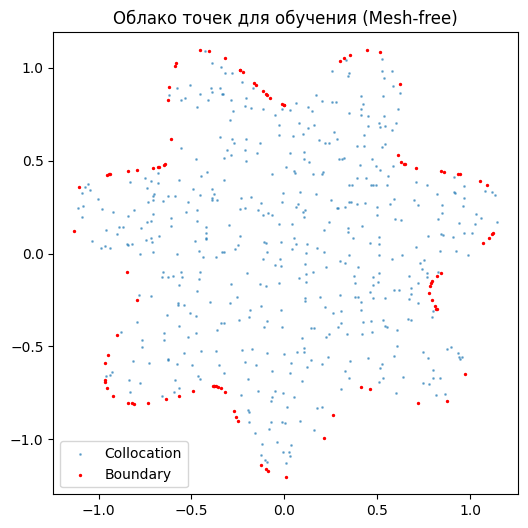

In [6]:
import matplotlib.pyplot as plt


# Рисуем точки коллокации, чтобы показать "бессеточность"
plt.figure(figsize=(6, 6))
plt.scatter(XY_collocation[:,0], XY_collocation[:,1], s=1, alpha=0.5, label='Collocation')
plt.scatter(XY_boundary[:,0], XY_boundary[:,1], s=2, c='r', label='Boundary')
plt.title("Облако точек для обучения (Mesh-free)")
plt.axis('equal')
plt.legend()
plt.show()

## 2. Точное решение (Method of Manufactured Solutions) ##

Чтобы проверить точность метода, мы будем использовать аналитическое решение

$$ u_{exact} = \sin(3x) \cdot \cos(3y) $$

Тогда, подставив его в уравнение Пуассона $-\Delta u = f$, найдем правую часть $f$:
$$ \frac{\partial^2 u}{\partial x^2} = -9 \sin(3x)\cos(3y) = -9 u $$
$$ \frac{\partial^2 u}{\partial y^2} = -9 \sin(3x)\cos(3y) = -9 u $$
$$ f(x,y) = -(-9u - 9u) = 18 u $$

То есть мы будем решать уравнение:
$$ -\Delta u = 18 \sin(3x)\cos(3y) $$
с граничными условиями Дирихле, взятыми из точного решения.

In [7]:
def exact_u(x, y):
    """Точное решение (универсальная функция: работает и с Tensor, и с NumPy)"""
    if torch.is_tensor(x):
        return torch.sin(3*x) * torch.cos(3*y)
    return np.sin(3*x) * np.cos(3*y)

In [8]:
# Значения u на границе (берем из точного решения)
# Теперь u_bnd_true будет тензором, что правильно для обучения
u_bnd_true = exact_u(x_bnd, y_bnd)

In [9]:
def source_f(x, y):
    # f(x,y) для уравнения Laplace(u) + f = 0
    # Здесь используем только torch, так как эта функция вызывается внутри loss с градиентами
    return 18 * torch.sin(3*x) * torch.cos(3*y)

## 3. Нейросеть и Физика ##

In [10]:
def poisson_loss(model, x, y):
    """
    Вычисление невязки уравнения Пуассона:
    Loss = mean( (-Laplace(u) - f)^2 )
    """
    x.requires_grad = True
    y.requires_grad = True
    
    u = model(x, y)
    
    # Первые производные
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    
    # Вторые производные
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    
    # Левая часть уравнения (-Laplace)
    lhs = -(u_xx + u_yy)
    
    # Правая часть (Source term)
    rhs = source_f(x, y)
    
    return torch.mean((lhs - rhs)**2)

 Теорема (Цыбенко, 1989) гласит, что нейросеть с одним скрытым слоем может аппроксимировать любую непрерывную функцию на компакте с любой заданной точностью, если предоставить достаточное количество нейронов.

In [11]:
class PINN_2D(nn.Module):
    def __init__(self):
        super().__init__()
        # Вход: 2 координаты (x, y)
        # Выход: 1 температура (u)
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            # nn.Linear(64, 64), nn.Tanh(),
            # nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Xavier initialization
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x, y):
        # Конкатенация координат
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

## 4. Подготовка данных и Обучение ##

In [12]:
# Модель
model = PINN_2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10001

print("Начинаем обучение...")
start = time.time()
history = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Loss на границе (BC)
    u_bnd_pred = model(x_bnd, y_bnd)
    loss_bc = torch.max((u_bnd_pred - u_bnd_true)**2)
    
    # Loss внутри области (Physics)
    loss_phys = poisson_loss(model, x_col, y_col)
    
    # Суммарный Loss
    loss = loss_bc + loss_phys
    
    loss.backward()
    optimizer.step()
    
    history.append(loss.item())

    if loss.item() < 0.0005:
        break

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f} (BC: {loss_bc.item():.5f}, Phys: {loss_phys.item():.5f})")

print(f"Время обучения: {time.time() - start:.2f} сек, эпоха {epoch}")

Начинаем обучение...
Epoch 0: Loss 82.49859 (BC: 1.28470, Phys: 81.21389)
Epoch 100: Loss 81.83112 (BC: 0.72046, Phys: 81.11066)
Epoch 200: Loss 81.11553 (BC: 0.69320, Phys: 80.42233)
Epoch 300: Loss 77.64362 (BC: 0.68270, Phys: 76.96091)
Epoch 400: Loss 68.03857 (BC: 0.58952, Phys: 67.44905)
Epoch 500: Loss 52.71235 (BC: 0.35189, Phys: 52.36045)
Epoch 600: Loss 36.68310 (BC: 0.28395, Phys: 36.39915)
Epoch 700: Loss 22.34159 (BC: 0.18428, Phys: 22.15731)
Epoch 800: Loss 12.68998 (BC: 0.33606, Phys: 12.35392)
Epoch 900: Loss 8.17158 (BC: 0.44788, Phys: 7.72370)
Epoch 1000: Loss 6.64252 (BC: 0.70172, Phys: 5.94081)
Epoch 1100: Loss 5.92776 (BC: 0.80167, Phys: 5.12609)
Epoch 1200: Loss 5.40716 (BC: 0.87029, Phys: 4.53687)
Epoch 1300: Loss 4.97981 (BC: 0.91750, Phys: 4.06231)
Epoch 1400: Loss 4.55509 (BC: 0.88807, Phys: 3.66702)
Epoch 1500: Loss 4.17852 (BC: 0.87624, Phys: 3.30228)
Epoch 1600: Loss 3.77723 (BC: 0.81388, Phys: 2.96334)
Epoch 1700: Loss 3.40377 (BC: 0.73114, Phys: 2.67263)
E

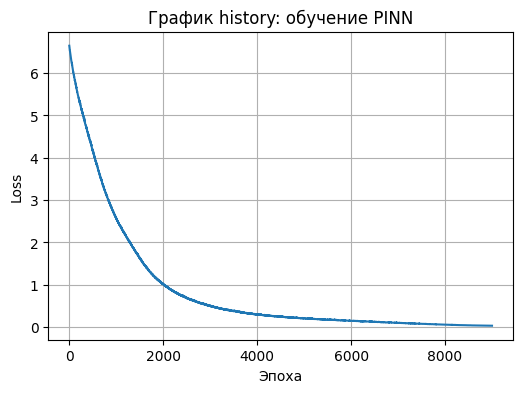

In [13]:

plt.figure(figsize=(6, 4))
plt.plot(history[1000:])
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('График history: обучение PINN')
plt.grid(True)
plt.show()




## 5. Визуализация ##

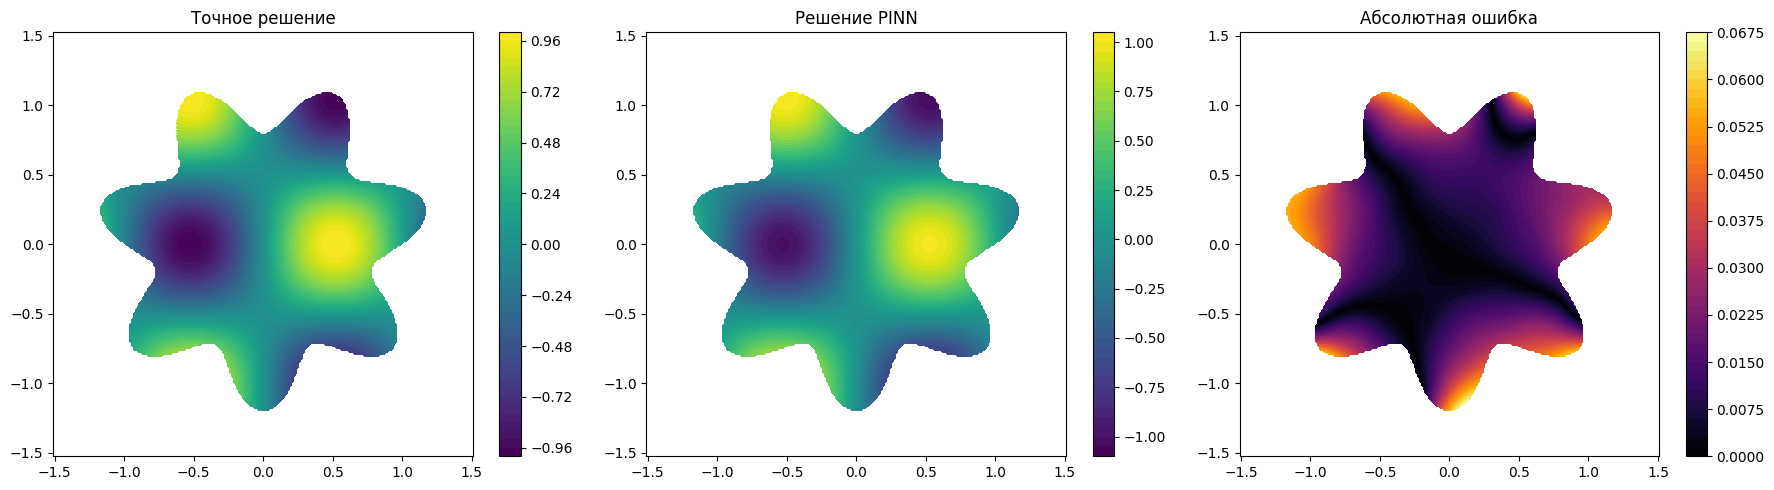

In [14]:
# Подготовка сетки для рисования
# Мы создаем квадратную сетку, но рисуем только то, что внутри шестеренки
x_range = np.linspace(-1.3, 1.3, 200)
y_range = np.linspace(-1.3, 1.3, 200)
X, Y = np.meshgrid(x_range, y_range)

# Маска для скрытия внешних точек
mask = is_inside_gear(X, Y)
# Делаем NaN там, где точки снаружи, чтобы matplotlib не рисовал их
X_masked = np.where(mask, X, np.nan)
Y_masked = np.where(mask, Y, np.nan)

# Предсказание нейросети
x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32).to(device)
y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32).to(device)

with torch.no_grad():
    u_pred_flat = model(x_flat, y_flat).cpu().numpy()

U_pred = u_pred_flat.reshape(X.shape)
U_pred_masked = np.where(mask, U_pred, np.nan)

# Точное решение
U_true_masked = np.where(mask, exact_u(X, Y), np.nan)
# Ошибка
Error_masked = np.abs(U_true_masked - U_pred_masked)

# Рисуем
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.contourf(X, Y, U_true_masked, levels=50, cmap='viridis')
plt.colorbar()
plt.title("Точное решение")
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.contourf(X, Y, U_pred_masked, levels=50, cmap='viridis')
plt.colorbar()
plt.title("Решение PINN")
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.contourf(X, Y, Error_masked, levels=50, cmap='inferno')
plt.colorbar()
plt.title("Абсолютная ошибка")
plt.axis('equal')

plt.tight_layout()
plt.show()
